<a href="https://colab.research.google.com/github/xvillarreald-max/ARTIFICIAL_INTELLIGENCE_TEAMXBDC/blob/main/FINAL_PROJECT_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Final** **Project**: Intelligent Medical Image Classification
Brain Tumor Detection from MRI Scans using VGG16 Transfer Learning

Ximena Villarreal Dávila

ID: 2177714

Benito Woo Zozaya

ID: 2177866

David Palma Cabañez

ID: 2177805

Carlos Arturo Arguelles Segura

ID: 2096281

CLASS: ARTIFICIAL INTELLIGENCE

Class schedule: N1

DATA LOADING AND PRE-PROCESSING

First we import the libraries

In [15]:
import os
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

This is to accelerate the runtime for the code (Changing the execution environment) because we need to have it quickly TT n TT

In [2]:
print("Versión de TensorFlow:", tf.__version__)
print("GPU Disponible: ", tf.config.list_physical_devices('GPU'))

Versión de TensorFlow: 2.20.0
GPU Disponible:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Download the dataset


We use the code that Kagglehub provides us

In [3]:
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Path to dataset files:", path)

# Ver qué carpetas contiene el directorio descargado
print("Contenido del directorio:", os.listdir(path))

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset
Contenido del directorio: ['Training', 'Testing']


We define the dataset that we will use to train the model, because Kaggle has two datasets, one which we will use for the testing of the model.
In this part we will also choose the parameters of the image and normalize it

In [29]:
# Definir la ruta de entrenamiento usando el 'path' que nos dio kagglehub
DATASET_DIR = os.path.join(path, 'Training')

# Parámetros
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# 1. Scale Normalization (0-255 a [0, 1]) y división de Validación (20%)
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# 2. Resizing y carga de datos de Entrenamiento
train_generator = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

# 3. Resizing y carga de datos de Validación
validation_generator = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print("Clases detectadas en el set médico:", train_generator.class_indices)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Clases detectadas en el set médico: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


The following cell is for checking that the imgaes where correctly loaded and normalized only

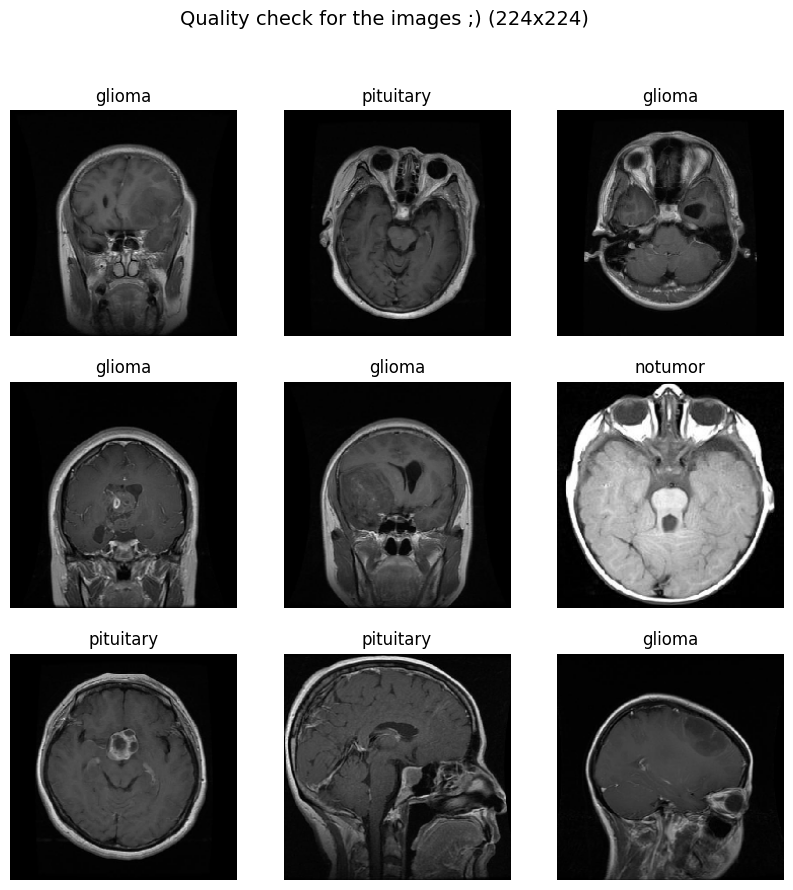

In [30]:
# Tomar un lote para inspección visual de control de calidad
images, labels = next(train_generator)
class_names = list(train_generator.class_indices.keys())

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])  # Se visualiza correctamente gracias a la normalización [0,1]
    class_idx = np.argmax(labels[i])
    plt.title(class_names[class_idx])
    plt.axis("off")
plt.suptitle("Quality check for the images ;) (224x224)", fontsize=14)
plt.show()

Next we adjust the dataset robustness, so we add some flips and rotations

In [11]:
# Generador de Entrenamiento con Aumentación de Datos e Integración de Escala [0,1]
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,       # Rotaciones leves (simula ligeras variaciones de postura en el imán)
    width_shift_range=0.05,  # Desplazamiento horizontal mínimo
    height_shift_range=0.05, # Desplazamiento vertical mínimo
    horizontal_flip=True,    # Volteo horizontal (las estructuras cerebrales siguen siendo válidas)
    validation_split=0.2     # Separación del 20% para validación
)

# Generador de Validación
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Conectar con las carpetas usando el path de kagglehub
train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

validation_generator = validation_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.


MACHINE LEARNING AND MODEL DESCRIPTION

Transfer learning: We decided to use this type of pre-trained model because they already have been trained and can perform more efficiently a specific task, has a better accuracy and it can work with a sample of fewer data.

We used the VGG16 because it has a simple architecture and sensibility to textures and contrasts, this characteristic for this project is essential because we are working with medical imagenology.

In [12]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout

def build_transfer_learning_model(input_shape=(224, 224, 3), num_classes=4):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)

    # Congelar los pesos del modelo base
    base_model.trainable = False

    # Construir la nueva cabeza de clasificación sobre la base congelada
    x = Flatten()(base_model.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model

# Volver a instanciar y probar
tl_model = build_transfer_learning_model()
tl_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,500 (80.64 MB)

 Trainable params: 6,423,812 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

TRAINING AND TESTING PROCESS

Changing the GPU in the execution environment makes the runtime for the training actually go super quickly :)))

In [13]:
# Definición de hiperparámetros requeridos
EPOCHS = 15  # Puedes ajustar la cantidad según el tiempo disponible
OPTIMIZER = tf.keras.optimizers.Adam(learning_rate=0.001)
LOSS_FUNCTION = 'categorical_crossentropy'

# Compilar el modelo de Transfer Learning (VGG16)
tl_model.compile(optimizer=OPTIMIZER, loss=LOSS_FUNCTION, metrics=['accuracy'])

# Entrenar el modelo de Transfer Learning
print("Entrenando Transfer Learning CNN (VGG16)")
history_tl = tl_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS
)

Entrenando Transfer Learning CNN (VGG16)
Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 101s 607ms/step - accuracy: 0.7308 - loss: 0.7998 - val_accuracy: 0.8661 - val_loss: 0.3768
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 72s 512ms/step - accuracy: 0.8275 - loss: 0.4685 - val_accuracy: 0.8893 - val_loss: 0.3601
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 75s 533ms/step - accuracy: 0.8214 - loss: 0.4619 - val_accuracy: 0.9018 - val_loss: 0.2874
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 72s 515ms/step - accuracy: 0.8299 - loss: 0.4246 - val_accuracy: 0.8929 - val_loss: 0.2724
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 516ms/step - accuracy: 0.8315 - loss: 0.4260 - val_accuracy: 0.8875 - val_loss: 0.2800
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 73s 517ms/step - accuracy: 0.8373 - loss: 0.3977 - val_accuracy: 0.8929 - val_loss: 0.2856
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 73s 522ms/step - accuracy: 0.8326 - loss: 0.4051 - val_accuracy: 0.9054 - val_loss: 0.2544
Epoch 8/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 7

Obtaining sensitivity and specifity

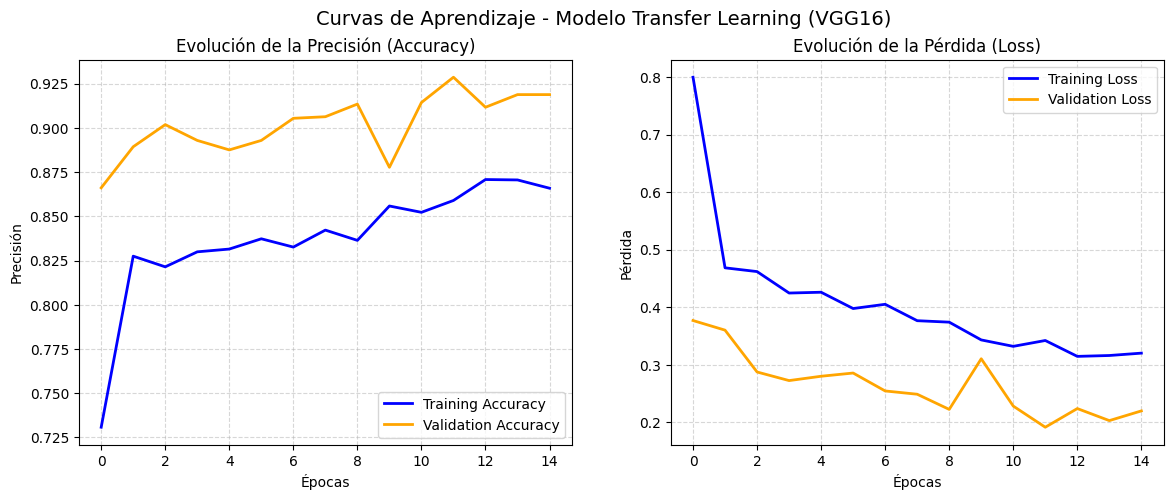

In [14]:
# Extraer métricas del historial de entrenamiento (VGG16)
acc = history_tl.history['accuracy']
val_acc = history_tl.history['val_accuracy']
loss = history_tl.history['loss']
val_loss = history_tl.history['val_loss']
epochs_range = range(len(acc))

# Configurar las gráficas
plt.figure(figsize=(14, 5))

# Gráfica de Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', lw=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', lw=2)
plt.title('Evolución de la Precisión (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', lw=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', lw=2)
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Curvas de Aprendizaje - Modelo Transfer Learning (VGG16)', fontsize=14)
plt.show()

35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 173ms/step
             REPORTE DE CLASIFICACIÓN CLÍNICA (SKLEARN)
              precision    recall  f1-score   support

      glioma       0.99      0.87      0.92       280
  meningioma       0.85      0.86      0.85       280
     notumor       0.99      0.96      0.98       280
   pituitary       0.87      0.98      0.92       280

    accuracy                           0.92      1120
   macro avg       0.92      0.92      0.92      1120
weighted avg       0.92      0.92      0.92      1120

             ESPECIFICIDAD POR CATEGORÍA
Especificidad para [glioma]: 0.9964
Especificidad para [meningioma]: 0.9476
Especificidad para [notumor]: 0.9964
Especificidad para [pituitary]: 0.9512


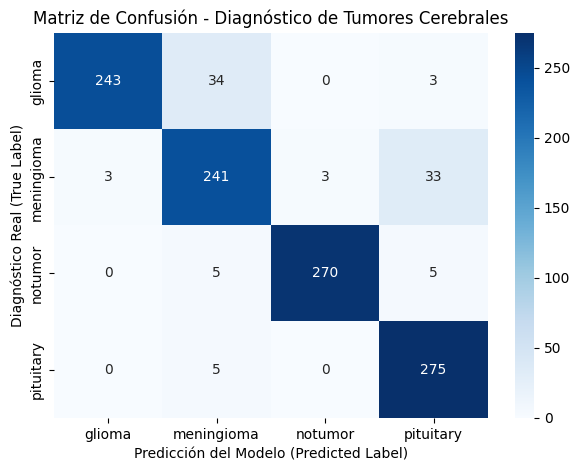

In [16]:
from sklearn.metrics import classification_report, confusion_matrix

# Asegurar que el generador de validación esté al inicio y extraer predicciones del modelo entrenado
validation_generator.reset()
predictions = tl_model.predict(validation_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = validation_generator.classes

# Obtener las etiquetas médicas de las carpetas
class_labels = list(validation_generator.class_indices.keys())

# 2. Desplegar el Reporte de Clasificación (Accuracy y Sensitivity/Recall de cajón)
print("="*60)
print("             REPORTE DE CLASIFICACIÓN CLÍNICA (SKLEARN)")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_labels))

# 3. Calcular e imprimir la Especificidad de forma manual para cada clase
print("="*60)
print("             ESPECIFICIDAD POR CATEGORÍA")
print("="*60)
cm = confusion_matrix(y_true, y_pred)

for i, class_name in enumerate(class_labels):
    tp = cm[i, i]
    fn = np.sum(cm[i, :]) - tp
    fp = np.sum(cm[:, i]) - tp
    tn = np.sum(cm) - (tp + fp + fn)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"Especificidad para [{class_name}]: {specificity:.4f}")

# Graficarla Matriz de Confusión
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Matriz de Confusión - Diagnóstico de Tumores Cerebrales')
plt.ylabel('Diagnóstico Real (True Label)')
plt.xlabel('Predicción del Modelo (Predicted Label)')
plt.show()

Model deployment and real world testing

Saving the trained model

Saved as this type of file (Hierarchical Data Format v5.) means that we have exported and saved the entire model in only one compressed file

In [17]:
tl_model.save('brain_tumor_vgg16_model.h5')
print("Modelo guardado exitosamente como 'brain_tumor_vgg16_model.h5'")

Modelo guardado exitosamente como 'brain_tumor_vgg16_model.h5'


Next comes the testing part, we use the testing dataset from kaggle, as the model has not see them (we used the training dataset)

In [18]:
import random
from tensorflow.keras.preprocessing.image import load_img, img_to_array

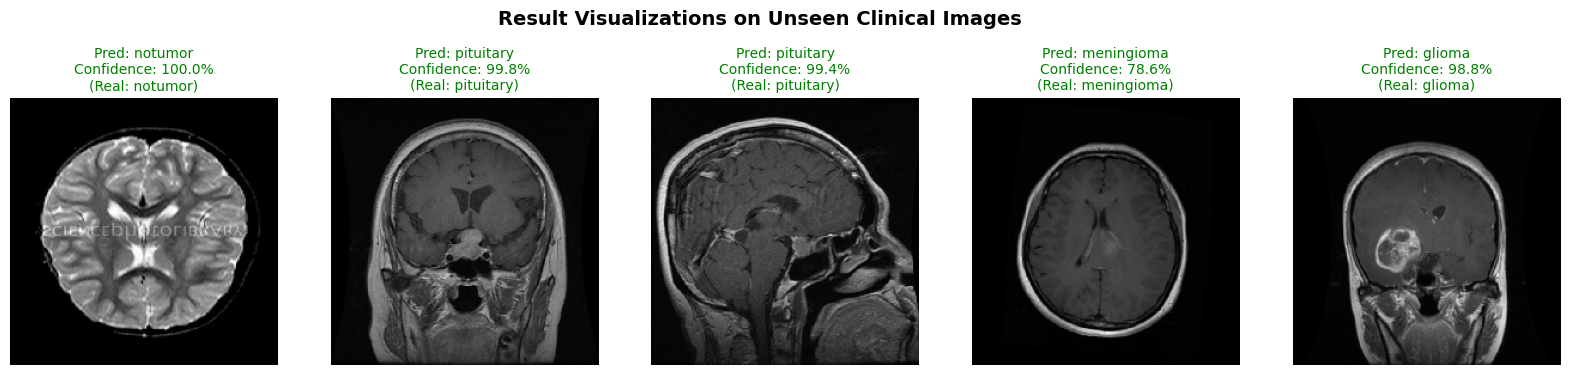

In [28]:
# Definir la ruta de la carpeta de Testing (Imágenes que el modelo jamás vio)
TEST_DIR = os.path.join(path, 'Testing')
class_names = list(train_generator.class_indices.keys())

# Recolectar rutas de imágenes de prueba aleatorias de las subcarpetas
all_test_images = []
for root, dirs, files in os.walk(TEST_DIR):
    for file in files:
        if file.lower().endswith(('png', 'jpg', 'jpeg')):
            all_test_images.append(os.path.join(root, file))

# Seleccionar al menos 5 imágenes aleatorias
selected_images = random.sample(all_test_images, 5)

# Configurar la visualización de los resultados
plt.figure(figsize=(20, 4))

for idx, img_path in enumerate(selected_images):
    # Pipeline de Preprocesamiento Idéntico
    img_raw = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img_raw)

    # Pipeline de Preprocesamiento Idéntico: Scale Normalization a [0, 1]
    img_scaled = img_array / 255.0

    # Expandir dimensiones para que coincida con el input del modelo (1, 224, 224, 3)
    img_input = np.expand_dims(img_scaled, axis=0)

    # Predicción e Inferencia del Modelo
    preds = tl_model.predict(img_input, verbose=0)
    pred_class_idx = np.argmax(preds[0])
    confidence_score = preds[0][pred_class_idx] * 100  # Convertir a porcentaje

    # Obtener el nombre de la etiqueta predicha y de la real (de la carpeta)
    predicted_label = class_names[pred_class_idx]
    actual_label = os.path.basename(os.path.dirname(img_path))

    # Graficar el resultado de la visualización solicitado en la rúbrica
    plt.subplot(1, 5, idx + 1)
    plt.imshow(img_scaled)

    # Formatear el título clínico según el ejemplo de la rúbrica
    title_text = f"Pred: {predicted_label}\nConfidence: {confidence_score:.1f}%\n(Real: {actual_label})"

    # Si la predicción es correcta verde, si falla rojo
    title_color = 'green' if predicted_label.lower() == actual_label.lower() else 'red'
    plt.title(title_text, color=title_color, fontsize=10)
    plt.axis('off')

plt.suptitle("Result Visualizations on Unseen Clinical Images", fontsize=14, fontweight='bold', y=1.05)
plt.show()